In [1]:
fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
               31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
               35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0,
               9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
               500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
               700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0,
               6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

In [2]:
import numpy as np

In [5]:
np.column_stack(([1, 2, 3, 4], [2,4,3,5]))

array([[1, 2],
       [2, 4],
       [3, 3],
       [4, 5]])

In [6]:
fish_data = np.column_stack((fish_length, fish_weight))


In [7]:
fish_data

array([[  25.4,  242. ],
       [  26.3,  290. ],
       [  26.5,  340. ],
       [  29. ,  363. ],
       [  29. ,  430. ],
       [  29.7,  450. ],
       [  29.7,  500. ],
       [  30. ,  390. ],
       [  30. ,  450. ],
       [  30.7,  500. ],
       [  31. ,  475. ],
       [  31. ,  500. ],
       [  31.5,  500. ],
       [  32. ,  340. ],
       [  32. ,  600. ],
       [  32. ,  600. ],
       [  33. ,  700. ],
       [  33. ,  700. ],
       [  33.5,  610. ],
       [  33.5,  650. ],
       [  34. ,  575. ],
       [  34. ,  685. ],
       [  34.5,  620. ],
       [  35. ,  680. ],
       [  35. ,  700. ],
       [  35. ,  725. ],
       [  35. ,  720. ],
       [  36. ,  714. ],
       [  36. ,  850. ],
       [  37. , 1000. ],
       [  38.5,  920. ],
       [  38.5,  955. ],
       [  39.5,  925. ],
       [  41. ,  975. ],
       [  41. ,  950. ],
       [   9.8,    6.7],
       [  10.5,    7.5],
       [  10.6,    7. ],
       [  11. ,    9.7],
       [  11.2,    9.8],


In [8]:
np.ones(5)

array([1., 1., 1., 1., 1.])

In [11]:
fish_target = np.concatenate((np.ones(35), np.zeros(14)))

In [13]:
from sklearn.model_selection import train_test_split

In [23]:
train_input, test_input, train_target, test_target = train_test_split(fish_data, fish_target, random_state=2)

In [25]:
print(train_input.shape, test_input.shape)

(36, 2) (13, 2)


In [26]:
print(train_target.shape,test_target.shape)

(36,) (13,)


In [27]:
print(test_target)

[1. 1. 0. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1.]


In [29]:
train_input, test_input, train_target, test_target = train_test_split(fish_data, fish_target, stratify = fish_target, random_state = 2)

In [30]:
print(test_target)

[1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1.]


In [32]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()
kn.fit(train_input, train_target)
kn.score(test_input, test_target)

1.0

In [34]:
print(kn.predict([[25, 150], [12, 20]]))

[0. 0.]


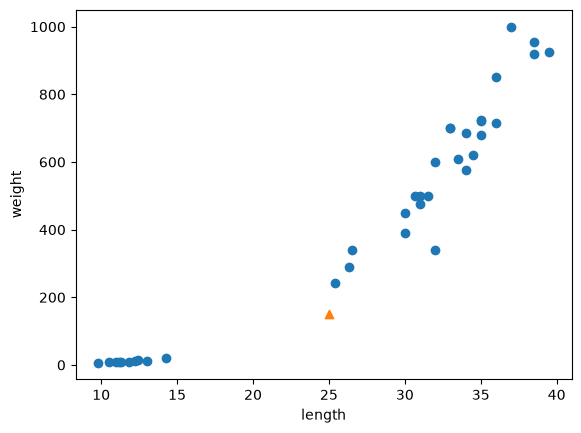

In [37]:
import matplotlib.pyplot as plt
plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(25, 150, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [44]:
distances, indexes = kn.kneighbors([[25, 150]])

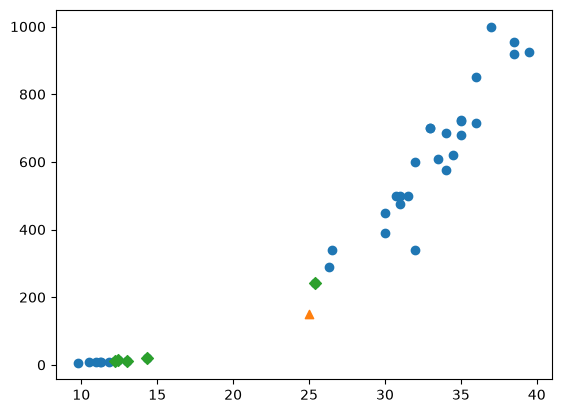

In [41]:
plt.scatter(train_input[: ,0], train_input[: , 1])
plt.scatter(25, 150, marker = '^')
plt.scatter(train_input[indexes, 0], train_input[indexes, 1], marker = 'D')

In [45]:
print(train_input[indexes])

[[[ 25.4 242. ]
  [ 14.3  19.7]
  [ 12.4  13.4]
  [ 13.   12.2]
  [ 12.2  12.2]]]


In [46]:
print(distances)

[[ 92.00086956 130.73859415 137.17988191 138.32150953 138.39320793]]


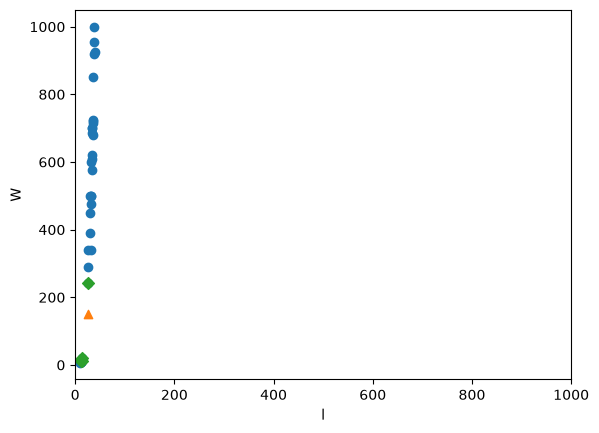

In [49]:
plt.scatter(train_input[:, 0], train_input[:, 1])
plt.scatter(25, 150, marker = '^')
plt.scatter(train_input[indexes, 0], train_input[indexes, 1], marker='D')
plt.xlim((0, 1000))
plt.xlabel("l")
plt.ylabel('W')
plt.show()

In [50]:
mean = np.mean(train_input, axis=0)
std = np.std(train_input, axis=0)


In [51]:
train_scaled = (train_input - mean)/std

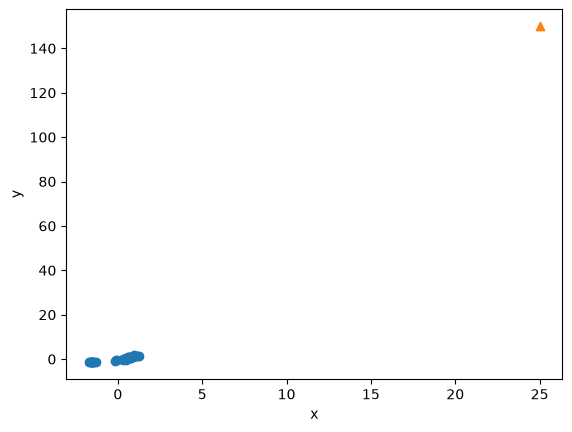

In [54]:
plt.scatter(train_scaled[:, 0], train_scaled[:,1])
plt.scatter(25, 150, marker='^')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

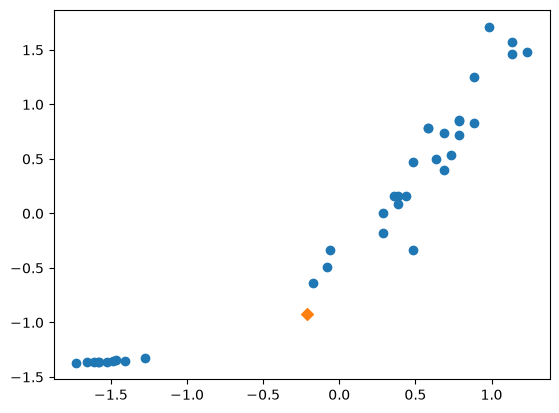

In [55]:
new = ([25, 150] - mean)/std
plt.scatter(train_scaled[:, 0], train_scaled[:, 1])
plt.scatter(new[0], new[1], marker='D')
plt.show()

In [58]:
import sklearn
sklearn.set_config(display='text')

In [59]:
kn.fit(train_scaled, train_target)

KNeighborsClassifier()

In [60]:
test_scaled = (test_input - mean)/std

In [61]:
kn.score(test_scaled, test_target)

1.0

In [62]:
print(kn.predict([new]))

[1.]


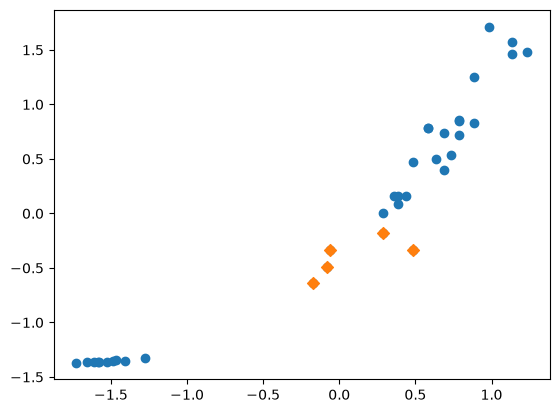

In [63]:
distances, indexes = kn.kneighbors([new])
plt.scatter(train_scaled[:,0], train_scaled[:, 1])
plt.scatter(train_scaled[indexes, 0], train_scaled[indexes, 1], marker='D')
plt.show()